## Note on Labs and Assignments:
**🔧 Look for the wrench emoji 🔧** it highlights where you're expected to take action!

These sections are graded and are not optional.

# IS 4487 Lab 4: Data Understanding

### Outline
- Load and preview a real-world dataset
- Inspect structure and identify data quality issues, such as missing or unusual data
- Perform basic grouped summaries to see trends

We are focused on the data understanding phase in business analytics. The tasks in this lab will help you figure out what the data actually contains before you start making decisions or building models. By exploring the dataset, you can identify key details such as the meaning of each column, the types of data (numeric, categorical, etc.), the presence of missing or inconsistent values, and the overall size and structure of the data. It's also important to look for patterns, unusual values, or outliers that could affect your analysis. Taking the time to understand your data early helps prevent mistakes, ensures your analysis is accurate, and guides you toward asking the right questions.

## SF Rentals - Business Context

This dataset represents actual rental listings in the San Francisco housing market, which is known for its high prices, competitive demand, and neighborhood-level variation. In a business context, this type of data could be used by real estate companies, rental platforms, investors, or property managers to better understand pricing trends and market dynamics. The variables provide multiple angles for analysis: pricing (`price`) can be compared with property features like size (`sqft`), bedrooms and bathrooms, and whether the listing is a full apartment or just a room; location data (`nhood`, `lat`, `lon`) allows for geographic analysis of rent differences across neighborhoods; and time variables (`date`, `year`) help track how the market changes over time.

Note that many of the columns (variables) will be empty. This is an unfortunate reality in the real world.

Each row represents one rental listing.

*Source: Pennington, Kate (2018). Bay Area Craigslist Rental Housing Posts, 2000-2018.*

### Data Dictionary

| Variable | Type | Description |
|---|---|---|
| post_id | Categorical | Unique listing ID |
| date | Numeric | Listing date (numeric format) |
| year | Integer | Year of listing |
| nhood | Categorical | Neighborhood |
| city | Categorical | City |
| county | Categorical | County |
| price | Numeric | Listing price (USD) |
| beds | Numeric | Number of bedrooms |
| baths | Numeric | Number of bathrooms |
| sqft | Numeric | Square footage |
| room_in_apt | Binary | Entire apartment (0) or a single room within an apartment (1) |
| address | Categorical | Street address |
| lat | Numeric | Latitude |
| lon | Numeric | Longitude |
| title | Text | Listing title |
| descr | Text | Listing description |
| details | Text | Additional details |

## 1. Importing the Data

**Instructions:**
- Import the pandas library.
- Import data from the `rent.csv` into a dataframe.
- Use `.info()` and `.head()` to inspect the structure and preview the data.

In [1]:
import pandas as pd

url = 'https://raw.githubusercontent.com/Stan-Pugsley/is_4487_base/refs/heads/main/DataSets/rent.csv'
df = pd.read_csv(url, low_memory=False)

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200810 entries, 0 to 200809
Data columns (total 17 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   post_id      200810 non-null  str    
 1   date         200797 non-null  str    
 2   year         200796 non-null  float64
 3   nhood        200796 non-null  str    
 4   city         200796 non-null  str    
 5   county       199402 non-null  str    
 6   price        200796 non-null  float64
 7   beds         194188 non-null  float64
 8   baths        42675 non-null   float64
 9   sqft         64679 non-null   float64
 10  room_in_apt  200796 non-null  float64
 11  address      3908 non-null    str    
 12  lat          7651 non-null    float64
 13  lon          4312 non-null    float64
 14  title        198279 non-null  str    
 15  descr        3254 non-null    str    
 16  details      8015 non-null    str    
dtypes: float64(8), str(9)
memory usage: 26.0 MB


In [2]:
df.head()

,post_id,date,year,nhood,city,county,price,beds,baths,sqft,room_in_apt,address,lat,lon,title,descr,details
0,pre2013_134138,20050111,2005.0,alameda,alameda,alameda,1250.0,2.0,2.0,NaN,0.0,NaN,NaN,NaN,$1250 / 2br - 2BR/2BA 1145 ALAMEDA DE LAS PU...,NaN,NaN
1,pre2013_135669,20050126,2005.0,alameda,alameda,alameda,1295.0,2.0,NaN,NaN,0.0,NaN,NaN,NaN,$1295 / 2br - Walk the Beach! 1 FREE MONTH + $...,NaN,NaN
2,pre2013_127127,20041017,2004.0,alameda,alameda,alameda,1100.0,2.0,NaN,NaN,0.0,NaN,NaN,NaN,$1100 / 2br - cottage,NaN,NaN
3,pre2013_68671,20120601,2012.0,alameda,alameda,alameda,1425.0,1.0,NaN,735.0,0.0,NaN,NaN,NaN,$1425 / 1br - 735ft² - BEST LOCATION SOUTHSHOR...,NaN,NaN
4,pre2013_127580,20041021,2004.0,alameda,alameda,alameda,890.0,1.0,NaN,NaN,0.0,NaN,NaN,NaN,"$890 / 1br - Classy ""Painted Lady"" VICTORIAN -...",NaN,NaN


### 🔧 Do the following - Part 1
Add one line of code to print the number of rows and columns.

In [3]:
print(f"Rows: {df.shape[0]:,}   Columns: {df.shape[1]}")

Rows: 200,810   Columns: 17


## 2. Inspecting the Data

**Instructions:**
- Identify missing values.
- Check data types are correct (e.g., dates, numeric columns).
- Check for outliers in key numeric variables like price, sqft, beds, or baths.

**Think about:**
- Are there missing values?
- Do the data types look appropriate?

In [4]:
# Check for missing values
df.isnull().sum()

post_id             0
date               13
year               14
nhood              14
city               14
county           1408
price              14
beds             6622
baths          158135
sqft           136131
room_in_apt        14
address        196902
lat            193159
lon            196498
title            2531
descr          197556
details        192795
dtype: int64

In [5]:
# Basic summary statistics
df[['price', 'beds', 'baths', 'sqft']].describe()

,price,beds,baths,sqft
count,200796.000000,194188.000000,42675.000000,64679.000000
mean,2135.362746,1.889025,1.679086,1201.827688
std,1427.747903,1.079138,0.690509,5000.217864
min,220.000000,0.000000,1.000000,80.000000
25%,1295.000000,1.000000,1.000000,750.000000
50%,1800.000000,2.000000,2.000000,1000.000000
75%,2505.000000,3.000000,2.000000,1360.000000
max,40000.000000,12.000000,8.000000,900000.000000


In [6]:
# Check data types
df.dtypes

post_id            str
date               str
year           float64
nhood              str
city               str
county             str
price          float64
beds           float64
baths          float64
sqft           float64
room_in_apt    float64
address            str
lat            float64
lon            float64
title              str
descr              str
details            str
dtype: object

### 🔧 Do the following - Part 2
Use `.describe()` to inspect the square footage (`sqft`) by itself.

In [7]:
df['sqft'].describe()

count     64679.000000
mean       1201.827688
std        5000.217864
min          80.000000
25%         750.000000
50%        1000.000000
75%        1360.000000
max      900000.000000
Name: sqft, dtype: float64

### Reflection:
**2.1. What patterns or issues do you see with square footage values? Is there anything unusual?**

✍️ **Your Response:**

**2.1.** Square footage is the least trustworthy variable in this file, for two separate reasons.

The first is coverage. Only 64,679 of the 200,810 listings report a square footage at all, roughly 32 percent. Every statistic below is therefore describing a self-selected third of the market rather than the market itself. Listings that bother to publish square footage skew toward larger, professionally marketed units, so the reported average is almost certainly higher than the true average across all rentals.

The second is the range. The minimum is 80 square feet, which is smaller than a parking space and reads as either a single room entered as the whole unit or a typo. The maximum is 900,000 square feet, which is roughly the size of a shopping mall and cannot be an apartment. That single value is doing real damage: the standard deviation comes out at 5,000 against a mean of 1,202, which is impossible for a variable whose interquartile range is only 750 to 1,360. Filtering above 5,000 square feet catches 207 listings, and spot-checking them turns up entries like a $1,100 rental listed at 28,000 square feet and a $2,500 rental at 30,000. Those are land parcels, lot sizes, or data entry errors, not living space.

The median of 1,000 sits well below the mean of 1,202, confirming the right skew. Before this column is usable it needs both an outlier filter and an explicit decision about the missing two thirds.

## 3. Basic Exploration

Use `groupby` and `value_counts` to summarize trends across neighborhoods and cities.

In [8]:
# Average price by neighborhood, highest first
df.groupby('nhood')['price'].mean().sort_values(ascending=False).head(10)

nhood
inverness                     5310.000000
atherton                      4536.010989
tiburon / belvedere           4265.346591
financial district            3958.161417
west portal / forest hills    3827.276119
saratoga                      3801.850900
kentfield / ross              3611.577855
los altos                     3605.047072
SOMA / south beach            3585.900793
pacific heights               3487.850301
Name: price, dtype: float64

In [9]:
# How many listings are available in each city
df['city'].value_counts().head(10)

city
san francisco    55730
san jose         13733
oakland           9443
santa rosa        6230
santa cruz        5464
san mateo         5127
sunnyvale         4526
mountain view     4414
berkeley          4201
santa clara       4171
Name: count, dtype: int64

### 🔧 Do the following - Part 3
Seek to understand the data by performing the following:
1. Group the listings by year and calculate the average price for each year. Sort the results by year.
2. Create a line chart to show the average price by year (from step 1)
3. Use `.value_counts()` on the `room_in_apt` column to see how common room rentals are.

In [10]:
# 1. Average price by year, sorted by year
avg_price_by_year = df.groupby('year')['price'].mean().sort_index()
avg_price_by_year

year
2000.0    1418.695652
2001.0    2070.038095
2002.0    1709.347079
2003.0    1587.705745
2004.0    1640.209812
2005.0    1525.475233
2006.0    1822.992589
2007.0    2152.303178
2008.0    2067.772489
2009.0    1951.866827
2010.0    1831.296377
2011.0    2082.872963
2012.0    2126.308527
2013.0    2679.816015
2014.0    2799.560424
2015.0    3016.057967
2016.0    2892.953247
2017.0    2998.658354
2018.0    2967.051076
Name: price, dtype: float64

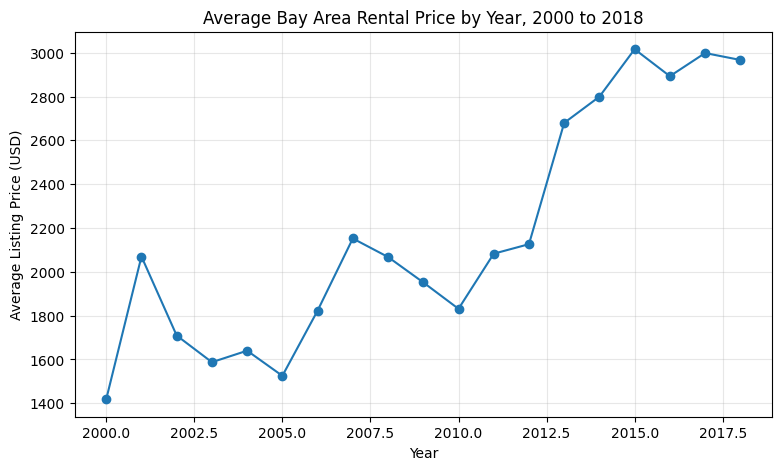

In [11]:
# 2. Line chart of average price by year
import matplotlib.pyplot as plt

avg_price_by_year.plot(marker='o', figsize=(9, 5))
plt.title('Average Bay Area Rental Price by Year, 2000 to 2018')
plt.xlabel('Year')
plt.ylabel('Average Listing Price (USD)')
plt.grid(alpha=0.3)
plt.show()

In [12]:
# 3. How common are room rentals?
df['room_in_apt'].value_counts()

room_in_apt
0.0    200511
1.0       285
Name: count, dtype: int64

## 4. Reflection:

✍️ **Your Response:**

**4.1. Explain, in detail, any trends you see with year and room_in_apt.**

**Year.** Average price does not rise in a straight line. It moves in three distinct phases that track the regional economy.

From 2000 through 2006 the average sits in a band roughly between $1,400 and $1,800, with a dip to $1,525 in 2005. This is the post dot-com period, when tech employment in the Bay Area contracted and rental demand softened. The market then runs up to $2,152 in 2007 before the financial crisis pushes it back down through 2010, bottoming at $1,831. From 2011 onward the direction is one way and steep: $2,083 in 2011, $2,680 in 2013, and a peak of $3,016 in 2015. The last three years flatten out between $2,893 and $2,999, which suggests the market hit an affordability ceiling rather than continuing to climb. End to end, average rent roughly doubles across the series.

Two cautions on reading that line. First, the listing counts per year are wildly uneven, from 23 records in 2000 to 41,847 in 2004, so the early points on the chart are built on almost no data and should not be given equal visual weight. Second, the mean sits above the median in every year, so the line is being lifted by luxury listings. Rerunning this with median would produce a lower and flatter curve that better represents a typical renter.

**room_in_apt.** The split is 200,511 whole units to 285 single rooms, with 14 nulls. Room rentals are about 0.14 percent of the dataset, which is functionally zero. This is worth stating plainly because it changes what the variable is good for. A binary with that little variation carries almost no predictive value in a pricing model, and any comparison of average price between the two groups would be comparing 200,000 observations to 285. The more likely explanation is that this reflects how the source platform categorized postings rather than the true prevalence of room rentals in the Bay Area, where shared housing is common. That gap between what the data says and what we know about the market is itself the finding.

**4.2. What would be the right way to handle missing data in several of the variables? Are those variables usable and useful?**

The right treatment depends entirely on how much is missing and whether the variable is a predictor or the target.

**Drop the rows.** `price` is missing on 14 records. Price is the target variable, so imputing it would mean inventing the answer we are trying to predict. Those 14 rows come out. The same 14 rows are also missing `year`, `nhood`, `city`, and `room_in_apt`, which suggests they are malformed records rather than partial ones. Removing 14 out of 200,810 costs nothing.

**Drop the columns.** `lat` is populated on 7,651 rows and `lon` on 4,312, roughly 4 percent and 2 percent. Imputing 96 percent of a coordinate would place properties at addresses they do not have. These are unusable for modeling and should be reserved for mapping the small subset that has them. `descr` (3,254 populated), `address` (3,908), and `details` (8,015) fall in the same category. `nhood` and `city` are nearly complete and already capture location in a form a model can use, so nothing of value is lost.

**Impute with a missingness flag.** `baths` is missing on 158,135 rows and `sqft` on 136,131, so both are absent on the majority. But unlike coordinates, these are genuinely predictive of rent, so throwing them away costs real signal. The better approach is to add a companion indicator column, for example `sqft_missing`, then impute the remaining values with the median rather than the mean, since the mean is contaminated by the 900,000 square foot outlier. The flag preserves the fact that a listing declined to publish the number, which is itself informative: budget and informal listings tend to omit details that professionally managed properties include.

**Straightforward imputation.** `beds` is missing on only 6,622 rows, about 3 percent. Median imputation is defensible here with minimal distortion.

**Complete but not useful.** `post_id` has zero missing values and zero analytical value. It is an arbitrary identifier with no relationship to price, and including it in a model would only produce spurious fit. Completeness is not the same as usefulness.

One order-of-operations note: outliers should be filtered before imputation, not after. Imputing with statistics calculated from a distribution that still contains a 900,000 square foot listing would push the error into every row that was missing.

## Export Your Notebook to Submit in Canvas
Use the instructions from Lab 1.

In [13]:
# !jupyter nbconvert --to html "lab_04_data_understanding.ipynb" 